# Music Recommendation System
## Clean training, evaluation, and export notebook

This notebook is a cleaned version of the original research notebook. It keeps the same
general story but removes duplicated experiments and website-integration code.

The workflow is intentionally straightforward:

1. Load the Spotify tracks dataset from `dataset.csv`.
2. Inspect and visualize the dataset.
3. Clean duplicate and invalid rows.
4. Prepare numerical audio features and genre text features.
5. Train a content-based recommendation model.
6. Create synthetic user interactions because the source dataset has no user ratings.
7. Train and evaluate a collaborative SVD model.
8. Define and evaluate a hybrid recommender.
9. Export the prepared catalogue and trained model artifacts for future use.

This file is about **offline model development**. It does not call an API. Later, a separate
application can receive a song's features from an API, pass those features to the exported
model objects, and return recommended tracks from the prepared catalogue.

The notebook trains three conceptual recommendation approaches:

- **Content-based filtering** compares musical characteristics.
- **Collaborative filtering** learns relationships from user-track interaction patterns.
- **Hybrid filtering** combines content, collaborative, and popularity scores.

The exported files are written into `model-data-clean`. This prevents an experimental run
from overwriting the files currently used by the working website.

# 1. Environment and libraries

The libraries used here have separate roles:

| Library | Role |
|---|---|
| `pandas` | Read CSV files and work with tables |
| `numpy` | Numerical calculations |
| `matplotlib`, `seaborn` | Charts for exploratory data analysis |
| `scikit-learn` | Scaling, TF-IDF text conversion, nearest neighbors, and metrics |
| `scipy` | Efficient sparse matrices |
| `surprise` | Collaborative filtering with SVD |
| `joblib` | Save trained Python objects |

If an import fails, install the missing package into the same Python environment used by
Jupyter. Package installation is shown as a comment so the notebook does not unexpectedly
modify your computer whenever it is run.

In [1]:
# Optional one-time installation command:
# %pip install pandas numpy matplotlib seaborn scikit-learn scipy scikit-surprise joblib

from __future__ import annotations

import json
import random
from pathlib import Path
from typing import Any

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.sparse import csr_matrix, hstack, save_npz
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MinMaxScaler, normalize
from surprise import Dataset, Reader, SVD

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

DATASET_PATH = Path("dataset.csv")
OUTPUT_DIR = Path("model-data-clean")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Libraries loaded.")
print("Dataset path:", DATASET_PATH.resolve())
print("Export directory:", OUTPUT_DIR.resolve())

Libraries loaded.
Dataset path: C:\Users\nadez\Desktop\final recommender systems\dataset.csv
Export directory: C:\Users\nadez\Desktop\final recommender systems\model-data-clean


# 2. Load the dataset

The source file is the Spotify Tracks Dataset. Each row describes one track and contains
identifiers, labels, popularity, and numerical audio characteristics.

Kaggle source:
https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset

Important groups of columns:

- **Identifiers:** `track_id`
- **Display labels:** `track_name`, `artists`, `album_name`
- **Categorical feature:** `track_genre`
- **Numerical features:** danceability, energy, tempo, loudness, and similar values
- **Baseline feature:** `popularity`

The first inspection is deliberately simple. Before training any model, we need to know the
size of the table, the column names, and whether the rows look sensible.

In [2]:
if not DATASET_PATH.exists():
    raise FileNotFoundError(
        "dataset.csv was not found. Place this notebook beside dataset.csv or update DATASET_PATH."
    )

raw_df = pd.read_csv(DATASET_PATH)
raw_df = raw_df.loc[:, ~raw_df.columns.str.startswith("Unnamed")]

print(f"Rows in the original dataset: {len(raw_df):,}")
print(f"Columns: {len(raw_df.columns)}")
print(list(raw_df.columns))

display(raw_df.head())

Rows in the original dataset: 114,000
Columns: 20
['track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


# 3. Initial data analysis

Data analysis comes before preprocessing because cleaning decisions should be based on what
actually exists in the dataset.

This section checks:

- missing values;
- duplicated Spotify track IDs;
- number of genres;
- distributions of popularity, tempo, and energy;
- correlation between numerical features;
- most frequent genres.

A duplicated track ID does not necessarily mean the source data is incorrect. The same track
can appear more than once because it is associated with more than one genre. During cleaning,
these rows will be merged into one track row while retaining all genre labels.

In [3]:
numeric_cols = [
    "danceability",
    "energy",
    "valence",
    "tempo",
    "acousticness",
    "instrumentalness",
    "loudness",
    "speechiness",
    "liveness",
    "popularity",
]

required_cols = [
    "track_id",
    "track_name",
    "artists",
    "album_name",
    "track_genre",
    "duration_ms",
    *numeric_cols,
]

missing_columns = sorted(set(required_cols).difference(raw_df.columns))
if missing_columns:
    raise ValueError(f"The dataset is missing required columns: {missing_columns}")

print("Missing values by column:")
display(raw_df[required_cols].isna().sum().sort_values(ascending=False).to_frame("missing"))

duplicate_rows = raw_df.duplicated(subset=["track_id"], keep=False).sum()
print(f"Rows whose track_id appears more than once: {duplicate_rows:,}")
print(f"Unique track IDs: {raw_df['track_id'].nunique():,}")
print(f"Unique genre labels: {raw_df['track_genre'].nunique():,}")

print("\nMost frequent genres:")
display(raw_df["track_genre"].value_counts().head(15).to_frame("tracks"))

Missing values by column:


,missing
track_name,1
artists,1
album_name,1
track_id,0
track_genre,0
duration_ms,0
danceability,0
energy,0
valence,0
tempo,0


Rows whose track_id appears more than once: 40,900
Unique track IDs: 89,741
Unique genre labels: 114

Most frequent genres:


,tracks
track_genre,
acoustic,1000
punk-rock,1000
progressive-house,1000
power-pop,1000
pop,1000
pop-film,1000
piano,1000
party,1000
pagode,1000


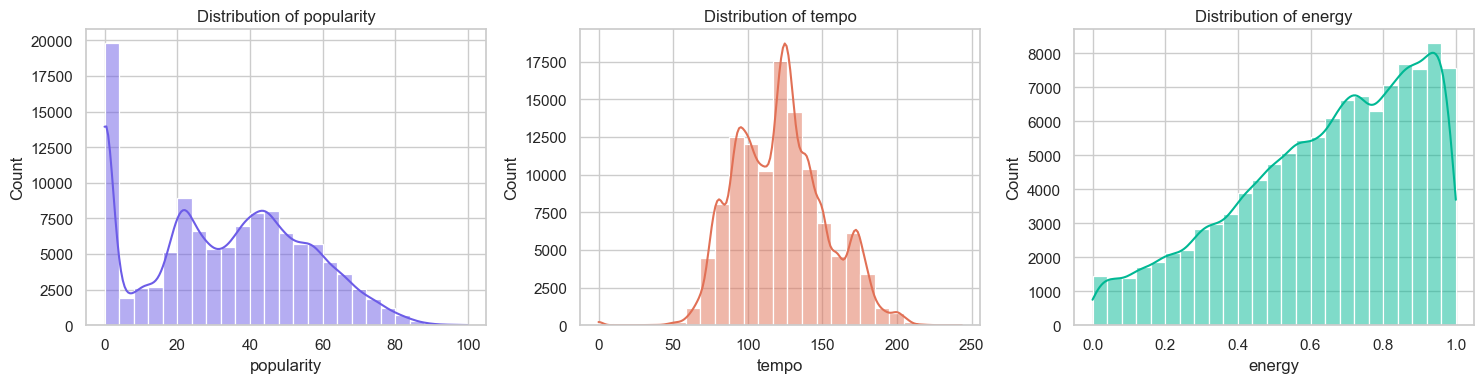

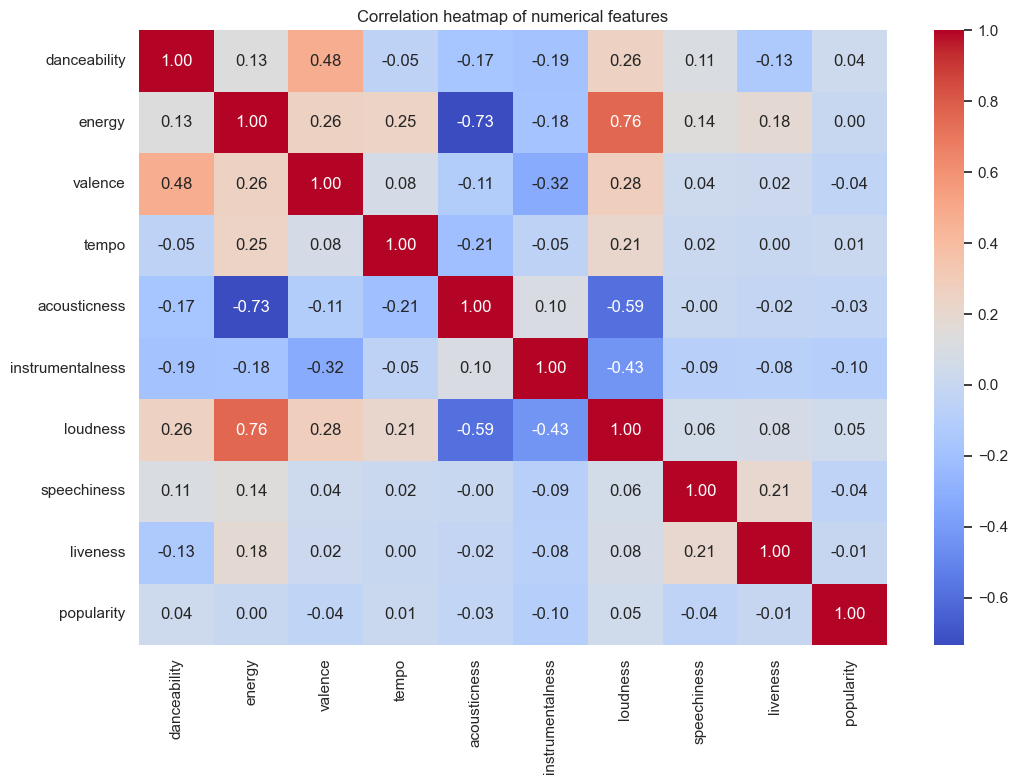

In [4]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.histplot(raw_df["popularity"], bins=25, kde=True, color="#6c5ce7")
plt.title("Distribution of popularity")

plt.subplot(1, 3, 2)
sns.histplot(raw_df["tempo"], bins=25, kde=True, color="#e17055")
plt.title("Distribution of tempo")

plt.subplot(1, 3, 3)
sns.histplot(raw_df["energy"], bins=25, kde=True, color="#00b894")
plt.title("Distribution of energy")

plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 8))
sns.heatmap(raw_df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation heatmap of numerical features")
plt.tight_layout()
plt.show()

# 4. Data cleaning and preprocessing

The cleaning pipeline performs five steps:

1. Remove rows with missing values in required columns.
2. Convert numerical columns to numerical values and remove invalid rows.
3. Merge duplicated Spotify track IDs, preserving multiple genres as a space-separated label.
4. Remove obvious outliers: tracks shorter than one minute, longer than ten minutes, or with
   non-positive tempo.
5. Reset row numbers after filtering.

After cleaning, one dataframe row represents one unique Spotify track.

The model representation is then prepared:

- Numerical columns are transformed to a comparable 0-to-1 range with `MinMaxScaler`.
- Genre text is transformed into TF-IDF values.
- Genre and numerical values are combined into one sparse feature matrix.

TF-IDF gives genre tokens numerical weights. Sparse matrices are used because each track has
only a small number of genres compared with the complete genre vocabulary.

In [5]:
df = raw_df.copy()

print("Rows before cleaning:", len(df))

df = df.dropna(subset=required_cols).copy()

for column in [*numeric_cols, "duration_ms"]:
    df[column] = pd.to_numeric(df[column], errors="coerce")
df = df.dropna(subset=[*numeric_cols, "duration_ms"]).copy()

aggregation = {
    column: "first"
    for column in df.columns
    if column not in {"track_id", "track_genre"}
}
aggregation["track_genre"] = lambda values: " ".join(
    sorted(set(str(value).lower().strip() for value in values if str(value).strip()))
)

df = df.groupby("track_id", as_index=False).agg(aggregation)

df["track_name"] = df["track_name"].astype(str).str.strip()
df["artists"] = df["artists"].astype(str).str.strip()
df["album_name"] = df["album_name"].astype(str).str.strip()
df["track_genre"] = df["track_genre"].astype(str).str.lower().str.strip()

df = df[
    (df["duration_ms"] >= 60_000)
    & (df["duration_ms"] <= 600_000)
    & (df["tempo"] > 0)
].copy()
df = df.reset_index(drop=True)


top_popular_tracks = df.sort_values("popularity", ascending=False).head(100)

top_popular_tracks[["track_id", "track_name", "artists", "popularity"]].to_csv(
    OUTPUT_DIR / "top_popular_tracks.csv",
    index=False,
)

print("Rows after cleaning:", len(df))
print("Unique track IDs after cleaning:", df["track_id"].nunique())
print("Duplicated track IDs after cleaning:", df.duplicated(subset=["track_id"]).sum())

display(df[["track_id", "track_name", "artists", "track_genre", "popularity"]].head())

Rows before cleaning: 114000
Rows after cleaning: 88271
Unique track IDs after cleaning: 88271
Duplicated track IDs after cleaning: 0


,track_id,track_name,artists,track_genre,popularity
0,0000vdREvCVMxbQTkS888c,Lolly,Rill,german,44
1,000CC8EParg64OmTxVnZ0p,It's All Coming Back To Me Now (Glee Cast Vers...,Glee Cast,club,47
2,000Iz0K615UepwSJ5z2RE5,Böxig Leise - Pig & Dan Remix,Paul Kalkbrenner;Pig&Dan,minimal-techno,22
3,000RDCYioLteXcutOjeweY,Teeje Week,Jordan Sandhu,hip-hop,62
4,000qpdoc97IMTBvF8gwcpy,Tief,Paul Kalkbrenner,minimal-techno,19


In [6]:
scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df[numeric_cols])

tfidf = TfidfVectorizer(stop_words="english")
genre_matrix = tfidf.fit_transform(df["track_genre"])

audio_weight = 0.20
genre_weight = 0.80

numerical_matrix = df_scaled[numeric_cols].to_numpy() * audio_weight
weighted_genre_matrix = genre_matrix * genre_weight
final_features = hstack([numerical_matrix, weighted_genre_matrix]).tocsr()
final_features_normalized = normalize(final_features, norm="l2", axis=1, copy=True)

print("Numerical feature matrix shape:", numerical_matrix.shape)
print("Genre TF-IDF matrix shape:", weighted_genre_matrix.shape)
print("Combined content matrix shape:", final_features.shape)
print("\nScaled numerical feature summary:")
display(df_scaled[numeric_cols].agg(["min", "max", "mean"]).round(3))

Numerical feature matrix shape: (88271, 10)
Genre TF-IDF matrix shape: (88271, 112)
Combined content matrix shape: (88271, 122)

Scaled numerical feature summary:


,danceability,energy,valence,tempo,acousticness,instrumentalness,loudness,speechiness,liveness,popularity
min,0.00,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
max,1.00,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
mean,0.55,0.637,0.474,0.432,0.328,0.169,0.747,0.069,0.209,0.333


# 5. Exploratory analysis after cleaning

The second analysis uses the cleaned track-level table. It answers a slightly different
question from the first inspection: what does the modelling dataset look like after duplicate
tracks have been merged?

A track with several genres stores those genres in one space-separated string. For genre-level
charts, the string is split temporarily so each genre can be counted independently. The
original track-level dataframe remains unchanged.

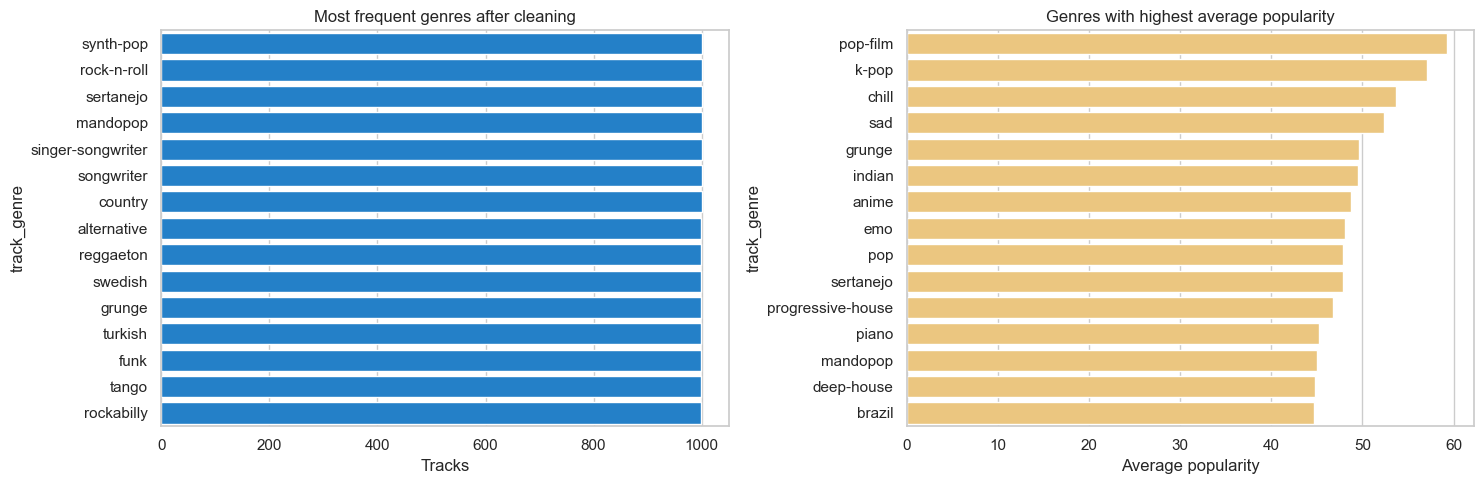

Most popular tracks after cleaning:


,track_name,artists,popularity,track_genre
43129,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,100,dance pop
32767,"Quevedo: Bzrp Music Sessions, Vol. 52",Bizarrap;Quevedo,99,hip-hop
67313,La Bachata,Manuel Turizo,98,latin latino reggae reggaeton
55519,I'm Good (Blue),David Guetta;Bebe Rexha,98,dance edm pop
14723,Tití Me Preguntó,Bad Bunny,97,latin latino reggae reggaeton
73160,Me Porto Bonito,Bad Bunny;Chencho Corleone,97,latin latino reggae reggaeton
59921,Under The Influence,Chris Brown,96,dance pop
59128,Efecto,Bad Bunny,96,latin latino reggae reggaeton
53122,I Ain't Worried,OneRepublic,96,piano pop rock
49172,As It Was,Harry Styles,95,pop


In [7]:
genre_df = df[["track_id", "track_genre", "popularity"]].copy()
genre_df["track_genre"] = genre_df["track_genre"].str.split()
genre_df = genre_df.explode("track_genre")
genre_df = genre_df[genre_df["track_genre"].notna() & (genre_df["track_genre"] != "")]

genre_frequency = genre_df["track_genre"].value_counts().head(15)
genre_popularity = (
    genre_df.groupby("track_genre")["popularity"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.barplot(x=genre_frequency.values, y=genre_frequency.index, color="#0984e3")
plt.title("Most frequent genres after cleaning")
plt.xlabel("Tracks")

plt.subplot(1, 2, 2)
sns.barplot(x=genre_popularity.values, y=genre_popularity.index, color="#fdcb6e")
plt.title("Genres with highest average popularity")
plt.xlabel("Average popularity")

plt.tight_layout()
plt.show()

print("Most popular tracks after cleaning:")
display(
    df[["track_name", "artists", "popularity", "track_genre"]]
    .sort_values("popularity", ascending=False)
    .head(10)
)

# 6. Train the content-based model

Content-based filtering compares tracks using the prepared feature matrix. The model does not
need user ratings. It answers:

> Which tracks have characteristics similar to this track?

`NearestNeighbors` is fitted with cosine distance. Cosine distance compares the direction of
feature vectors rather than their absolute size. This works well for a representation that
combines TF-IDF genre values and normalized numerical characteristics.

The input is a track from the prepared catalogue. The output is a table of nearby tracks from
the same catalogue.

The future website can use the full content model when another service supplies:

- the numerical audio values;
- `popularity`;
- `track_genre`.

A track-level genre is not always available from music APIs. An acceptable practical fallback
is to use the main artist's genres as an approximate genre proxy and document that choice.

The notebook therefore needs only one model and one future-input function. The function does
not call an API itself. It accepts a feature dictionary supplied by another component.

In [8]:
content_based_model = NearestNeighbors(
    n_neighbors=51, #default number of neighbours returned
    metric="cosine",
    algorithm="brute",
)
content_based_model.fit(final_features_normalized)

#dictionary with indices
track_id_to_index = {str(track_id): idx for idx, track_id in enumerate(df["track_id"])}

def recommend_content_by_track_id(track_id: str, top_k: int = 10) -> list:
    track_id = str(track_id)
    if track_id not in track_id_to_index:
        raise KeyError(f"Track ID is not present in the prepared catalogue: {track_id}")

    seed_index = track_id_to_index[track_id]
    distances, indices = content_based_model.kneighbors(final_features_normalized[seed_index], n_neighbors=top_k+1)
    
    recommended_indices = [int(index) for index in indices.flatten() if index!= seed_index][:top_k] #remove seed track from recommendations
    recommended_track_ids = df.iloc[recommended_indices]["track_id"].tolist()

    return recommended_track_ids


example_track_id = str(df.iloc[0]["track_id"])

print("Input song:")
display(df.iloc[[0]][["track_id", "track_name", "artists", "track_genre", "popularity"]])

recommended_ids = recommend_content_by_track_id(example_track_id, top_k=5)

print("Recommended songs:")
display(df.set_index("track_id").loc[recommended_ids][["track_name", "artists", "track_genre", "popularity"]].reset_index())


Input song:


,track_id,track_name,artists,track_genre,popularity
0,0000vdREvCVMxbQTkS888c,Lolly,Rill,german,44


Recommended songs:


,track_id,track_name,artists,track_genre,popularity
0,1PTt5Oa80JGSBCrzzfhtn6,Nur ein Wort,Lugatti & 9ine,german,40
1,1CZiOG1oqXnEHhvP9Y3ETa,Miami,Lil Shrimp;Princess Javel,german,42
2,4uQhntQHoQ1kyyrLLFl6PK,Drück den Benz weg,Nullzweizwei;RUFUZ;BAZU,german,37
3,6RXI2dGFYwWNdi2fWthp2w,6 Atzen,Teuterekordz,german,40
4,4EA3y8O2XYlQO1Wp7OWnU0,Sonnenstich,PA69,german,39


In [9]:
def input_features_to_vector(features: dict[str, Any]) -> csr_matrix:

    required = [*numeric_cols, "track_genre"]
    missing = [column for column in required if column not in features]
    if missing:
        raise ValueError(f"Input features are missing values: {missing}")

    numerical_row = pd.DataFrame([{column: float(features[column]) for column in numeric_cols}], columns=numeric_cols) #dataframe because scaler was trained on dataframe
    scaled_numerical = scaler.transform(numerical_row) * audio_weight
    genre_vector = tfidf.transform([str(features["track_genre"])]) * genre_weight #tfidf model
    combined = hstack([scaled_numerical, genre_vector]).tocsr() #csr is a compressed sparse row. it stores sparse vector (due to tfidf) efficiently (nonzero values and their positions)
    return normalize(combined, norm="l2", axis=1, copy=True) #l2 norm


def recommend_from_features(features: dict[str, Any],top_k: int = 10,) -> list:

    query_vector = input_features_to_vector(features)
    distances, indices = content_based_model.kneighbors(query_vector,n_neighbors=top_k+1)

    input_track_id = str(features.get("id", ""))

    recommended_indices = [int(index) for index in indices.flatten() if str(df.iloc[int(index)]["track_id"]) != input_track_id][:top_k] #if input track is in database and was recommended, remove it, if not we have top_k+1 recommendations, leave only top_k
    recommended_track_ids = df.iloc[recommended_indices]["track_id"].tolist()

    return recommended_track_ids



# 7. Create synthetic user interactions

The tracks dataset has no user-rating history. Collaborative filtering cannot be trained from
song characteristics alone, because its purpose is to learn from user behavior.

To demonstrate the pipeline, this section creates synthetic users:

- each simulated user receives several preferred genres;
- most of that user's sampled tracks come from preferred genres;
- preferred tracks are more likely to receive high ratings;
- non-preferred tracks are more likely to receive low ratings.

This is useful for building and testing a prototype. It must be described honestly: synthetic
interactions demonstrate that the pipeline works, but they do not prove real listener
preferences. A future study can replace this table with real interaction or survey data.

In [10]:
rng = np.random.default_rng(RANDOM_SEED)

num_users = 5_000
min_interactions_per_user = 50
max_interactions_per_user = 80
preferred_ratio = 0.70

ratings = np.asarray([1, 2, 3, 4, 5])
preferred_probs = np.asarray([0.03, 0.07, 0.20, 0.40, 0.30])
nonpreferred_probs = np.asarray([0.20, 0.35, 0.30, 0.12, 0.03])

genre_sets = df["track_genre"].str.split().apply(set).tolist()  #for each track, split its genre string into a set of genres
all_genres = sorted(set().union(*genre_sets))  #collect all unique genres from all tracks and sort them
all_track_indices = np.arange(len(df))

genre_to_indices = {}
for genre in all_genres:
    genre_to_indices[genre] = np.asarray([index for index, track_genres in enumerate(genre_sets) if genre in track_genres]) #maps genre to song indices with such genre

user_profile_rows = []
interaction_rows = []

for user_number in range(num_users):
    user_id = f"user_{user_number}"

    preferred_genres = sorted(rng.choice(all_genres, size=int(rng.integers(2, 5)), replace=False))
    preferred_genre_set = set(preferred_genres)

    preferred_indices = np.unique(np.concatenate([genre_to_indices[genre] for genre in preferred_genres]))
    nonpreferred_indices = np.setdiff1d(all_track_indices, preferred_indices)

    interaction_count = int(rng.integers(min_interactions_per_user, max_interactions_per_user + 1))
    preferred_count = int(round(interaction_count * preferred_ratio))
    nonpreferred_count = interaction_count - preferred_count

    selected_preferred = rng.choice(preferred_indices, size=min(preferred_count, len(preferred_indices)), replace=False)
    selected_nonpreferred = rng.choice(nonpreferred_indices, size=min(nonpreferred_count, len(nonpreferred_indices)), replace=False)

    user_profile_rows.append({"user_id": user_id, "preferred_genres": ",".join(preferred_genres)})

    for track_index in np.concatenate([selected_preferred, selected_nonpreferred]):
        track_index = int(track_index)
        is_preferred = bool(genre_sets[track_index] & preferred_genre_set) #checks if this track's genre is in a set of user's preffered genres
        probabilities = preferred_probs if is_preferred else nonpreferred_probs
        rating = int(rng.choice(ratings, p=probabilities))

        interaction_rows.append({
            "user_id": user_id,
            "track_id": str(df.iloc[track_index]["track_id"]),
            "rating": rating,
        })

user_profiles = pd.DataFrame(user_profile_rows)
interactions = pd.DataFrame(interaction_rows).drop_duplicates(subset=["user_id", "track_id"]).reset_index(drop=True) # a user may prefer several genres, and the same track could be selected through more than one genre path. so there could be duplicates

print(f"Synthetic users: {interactions['user_id'].nunique():,}")
print(f"Synthetic interactions: {len(interactions):,}")
print(f"Tracks covered by interactions: {interactions['track_id'].nunique():,} / {len(df):,}")
display(interactions.head())

Synthetic users: 5,000
Synthetic interactions: 323,782
Tracks covered by interactions: 85,106 / 88,271


,user_id,track_id,rating
0,user_0,7egP9xlnVieZab45uisr49,4
1,user_0,2go4N239uPaY9BuXjqBaN7,4
2,user_0,5bW5BtZD24h2zAAaFKet2M,4
3,user_0,33Y1jukFR76pj7TXFTHQBJ,2
4,user_0,3qcRxk7XZRzqul1MtfKmXN,4


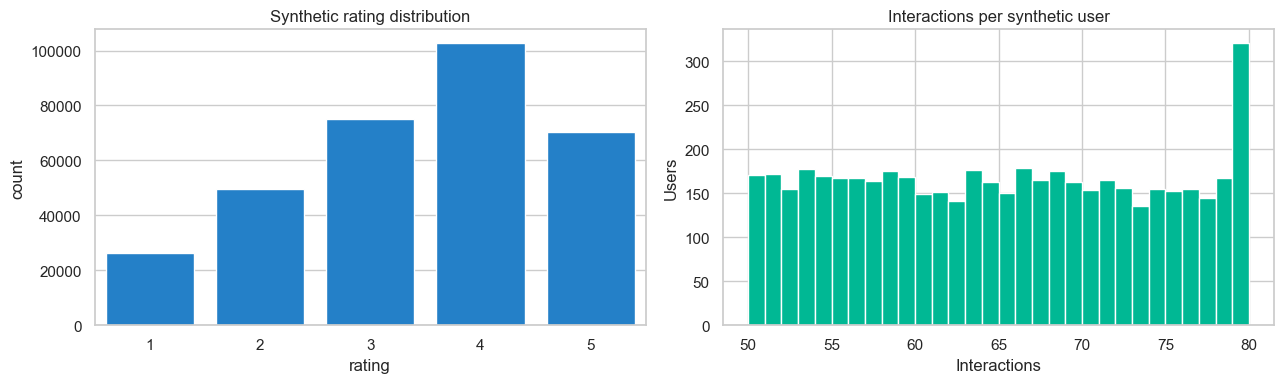

In [11]:
plt.figure(figsize=(13, 4))

plt.subplot(1, 2, 1)
sns.countplot(data=interactions, x="rating", order=[1, 2, 3, 4, 5], color="#0984e3")
plt.title("Synthetic rating distribution")

plt.subplot(1, 2, 2)
interactions.groupby("user_id").size().hist(bins=30, color="#00b894")
plt.title("Interactions per synthetic user")
plt.xlabel("Interactions")
plt.ylabel("Users")

plt.tight_layout()
plt.show()

# 8. Split interactions into training and test sets

Evaluation requires data that was not used for model fitting. For every synthetic user, part
of the interaction history is held out as test data.

- `train_interactions` are used to fit collaborative filtering.
- `test_interactions` are used to measure rating-prediction error and ranking quality.

Splitting by user ensures that the evaluation includes held-out tracks for known users rather
than accidentally testing only on the same rows used during training.

In [12]:
from sklearn.model_selection import train_test_split

train_interactions, test_interactions = train_test_split(
    interactions,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=interactions["user_id"], # when splitting into train and test, keep approximately the same proportion for each user (so if user1 has 100 interractions, 20%(20 interractions) is for test)
)

train_interactions = train_interactions.reset_index(drop=True)
test_interactions = test_interactions.reset_index(drop=True)

print(f"Training interactions: {len(train_interactions):,}")
print(f"Test interactions: {len(test_interactions):,}")
print(f"Users in training data: {train_interactions['user_id'].nunique():,}")
print(f"Users in test data: {test_interactions['user_id'].nunique():,}")

all_dataset_track_ids = set(df["track_id"].astype(str))
train_track_ids = set(train_interactions["track_id"].astype(str))
missing_track_ids = all_dataset_track_ids - train_track_ids
print("Tracks in dataset:", len(all_dataset_track_ids))
print("Tracks in training interactions:", len(train_track_ids))
print("Tracks missing from training:", len(missing_track_ids))

Training interactions: 259,025
Test interactions: 64,757
Users in training data: 5,000
Users in test data: 5,000
Tracks in dataset: 88271
Tracks in training interactions: 82269
Tracks missing from training: 6002


# 9. Train and evaluate collaborative filtering

Collaborative filtering learns from user-track ratings rather than audio characteristics.

This notebook uses Surprise `SVD`, a matrix-factorization model. It learns a compact latent
vector for each user and each track. Latent dimensions are not directly named features such as
tempo or energy. They represent patterns learned from interaction behavior.

For rating prediction, SVD estimates how a user might rate a track. Two metrics are reported:

- **RMSE**: root mean squared error. Larger mistakes receive a stronger penalty.
- **MAE**: mean absolute error. This is the average absolute prediction difference.

Smaller error values are better.

In [ ]:
reader = Reader(rating_scale=(1, 5))
train_dataset = Dataset.load_from_df(train_interactions[["user_id", "track_id", "rating"]], reader)
trainset = train_dataset.build_full_trainset()

collaborative_svd = SVD(
    n_factors=20,
    n_epochs=10,
    lr_all=0.002,
    reg_all=0.1,
    random_state=RANDOM_SEED,
    verbose=True,
)

collaborative_svd.fit(trainset)

test_predictions = [
    collaborative_svd.predict(user_id, track_id).est
    for user_id, track_id in zip(
        test_interactions["user_id"],
        test_interactions["track_id"],
    )
]

collaborative_rmse = float(
    np.sqrt(mean_squared_error(test_interactions["rating"], test_predictions))
)
collaborative_mae = float(
    mean_absolute_error(test_interactions["rating"], test_predictions)
)

print(f"Collaborative SVD RMSE: {collaborative_rmse:.4f}")
print(f"Collaborative SVD MAE:  {collaborative_mae:.4f}")

Processing epoch 0
Processing epoch 1
Processing epoch 2
Processing epoch 3
Processing epoch 4
Processing epoch 5
Processing epoch 6
Processing epoch 7
Processing epoch 8
Processing epoch 9
Processing epoch 10
Processing epoch 11
Processing epoch 12
Processing epoch 13
Processing epoch 14
Processing epoch 15
Processing epoch 16
Processing epoch 17
Processing epoch 18
Processing epoch 19
Collaborative SVD RMSE: 1.2375
Collaborative SVD MAE:  1.0387


In [14]:
from surprise.model_selection import GridSearchCV

param_grid = {
    "n_factors": [20, 50, 100],
    "n_epochs": [10, 20, 30],
    "lr_all": [0.002, 0.005, 0.01],
    "reg_all": [0.02, 0.05, 0.1],
}

grid_search = GridSearchCV(SVD, param_grid, measures=["rmse", "mae"], cv=3) #3 cross validations
grid_search.fit(train_dataset)

print(grid_search.best_score["rmse"])
print(grid_search.best_params["rmse"])

1.2203472405341023
{'n_factors': 20, 'n_epochs': 10, 'lr_all': 0.002, 'reg_all': 0.1}


In [15]:

# in surprise SVD collaborative_svd.pu are user factors, collaborative_svd.qi are item factors
#normalize all factors to use cosine simmilarity later
item_factors = normalize(collaborative_svd.qi)

#surprise creates its own inner ids
inner_id_to_track_id = [trainset.to_raw_iid(inner_id) for inner_id in range(trainset.n_items)]
track_id_to_inner_id = {trainset.to_raw_iid(inner_id): inner_id for inner_id in range(trainset.n_items)}

def recommend_svd_item_item(track_id: str, top_k: int = 10) -> list:
    track_id = str(track_id)

    if track_id not in track_id_to_inner_id:
        raise KeyError(f"Track is not in collaborative training data: {track_id}")
    
    seed_inner_id = track_id_to_inner_id[track_id]
    scores = item_factors @ item_factors[seed_inner_id]
    scores[seed_inner_id] = -np.inf #setting minimum score for seed song
    recommended_inner_ids = np.argsort(scores)[::-1][:top_k]
    recommended_track_ids = [inner_id_to_track_id[inner_id] for inner_id in recommended_inner_ids]
    return recommended_track_ids

example_track_id = str(train_interactions.iloc[0]["track_id"])

recommended_ids = recommend_svd_item_item(example_track_id, top_k=10)

display(pd.DataFrame({"track_id": recommended_ids}).merge(df, on="track_id")[["track_name", "artists", "track_genre", "popularity"]])

,track_name,artists,track_genre,popularity
0,Slow Laugh (feat. Nima Alizade),Asef Akbari;Nima Alizade,iranian,0
1,Lost,Hayd,singer-songwriter songwriter,58
2,Quiet Storm (with Zomboy),DJ Snake;Zomboy,electronic,47
3,5 Sentidos,Dvicio;Taburete,spanish,57
4,La Caída y la Gloria,Los Victorios,ska,32
5,Joker And The Thief,Wolfmother,blues garage psych-rock,68
6,Declaração de Amor / Pecado de Amor / Deixaria...,Murilo Huff,sertanejo,57
7,Again & Again,Roots Manuva,trip-hop,19
8,Christmas All Over Again,Tom Petty and the Heartbreakers,folk rock singer-songwriter songwriter,0
9,Do You Believe - Original Mix,Marshall Jefferson;Full Intention;Sleezy D,chicago-house,6


# 10. Define the hybrid recommender

Hybrid filtering combines several useful signals:

- **55% content similarity**: songs should have similar characteristics.
- **35% collaborative similarity**: songs should have related interaction patterns.
- **10% popularity**: a small stabilizing contribution from generally popular tracks.

The weights are explicit. They are not hidden inside the model and can be adjusted in future
experiments.

A hybrid recommender is a rule for combining trained components. It is not necessarily a
fourth object that requires a separate `.fit()` call. In this notebook, the content model and
SVD model are trained first, then their score arrays are combined.

In [16]:
content_weight = 0.55
collaborative_weight = 0.35
popularity_weight = 0.10

popularity_by_track_id = dict(zip(df["track_id"], df["popularity"])) 

def recommend_hybrid_by_track_id(track_id: str, top_k: int = 10) -> list:
  
    candidate_count = min(top_k * 3, 50)
    content_ids = recommend_content_by_track_id(track_id, top_k=candidate_count)

    try:
        collaborative_ids = recommend_svd_item_item(track_id, top_k=candidate_count)
    except KeyError:
        collaborative_ids = []

    candidate_ids = list(dict.fromkeys(content_ids + collaborative_ids)) #dictionary to remove duplicates
    scores = {candidate_id: popularity_weight * float(popularity_by_track_id.get(candidate_id, 0)) / 100 for candidate_id in candidate_ids} #if popularity not found, use 0, divide by 100 to normalize (popularity is from 0 to 100)

    for rank, candidate_id in enumerate(content_ids):
        scores[candidate_id] = scores.get(candidate_id, 0) + content_weight / (rank + 1) # traks closer to a seed track have lower rank

    for rank, candidate_id in enumerate(collaborative_ids):
        scores[candidate_id] = scores.get(candidate_id, 0) + collaborative_weight / (rank + 1)

    recommended_ids = sorted(scores, key=scores.get, reverse=True)[:top_k]
    return recommended_ids

example_track_id = str(df.iloc[0]["track_id"])

recommended_ids = recommend_hybrid_by_track_id(example_track_id, top_k=10)

print("Input song:")
display(df.iloc[[0]][["track_id", "track_name", "artists", "track_genre", "popularity"]])

print("Hybrid recommended songs:")
display(pd.DataFrame({"track_id": recommended_ids}).merge(df, on="track_id")[["track_id", "track_name", "artists", "track_genre", "popularity"]])

Input song:


,track_id,track_name,artists,track_genre,popularity
0,0000vdREvCVMxbQTkS888c,Lolly,Rill,german,44


Hybrid recommended songs:


,track_id,track_name,artists,track_genre,popularity
0,1PTt5Oa80JGSBCrzzfhtn6,Nur ein Wort,Lugatti & 9ine,german,40
1,5LpDSpcKH3jZEBHAF75oxX,"When She Showed me Love (from ""Toy Story"")",The Sleep Diaries,disney,18
2,1CZiOG1oqXnEHhvP9Y3ETa,Miami,Lil Shrimp;Princess Javel,german,42
3,4uQhntQHoQ1kyyrLLFl6PK,Drück den Benz weg,Nullzweizwei;RUFUZ;BAZU,german,37
4,6RXI2dGFYwWNdi2fWthp2w,6 Atzen,Teuterekordz,german,40
5,2vGDTOtslhkco6LVFfdEI2,Black Hole Sun,Soundgarden,alt-rock alternative grunge hard-rock metal,0
6,4EA3y8O2XYlQO1Wp7OWnU0,Sonnenstich,PA69,german,39
7,7kssBDkBUjGrHiQzN2VkYN,Armageddon X 7,Napalm Death,grindcore,15
8,2DX4Lj4wXV3VK1F8yl0x54,I.m.d.g,KazOnDaBeat;BHZ,german,37
9,4VI5qgaUOC4irfkOrzdG6w,Pitilla Ska,Sonora de Llegar,ska,34


# 11. Evaluate recommendation ranking

Rating-prediction metrics evaluate SVD, but a recommender should also be tested as a ranking
system.

This simple evaluation uses held-out liked tracks:

1. Select an eligible synthetic user.
2. Choose one liked training track as a seed.
3. Treat the user's liked test tracks as relevant targets.
4. Generate top-10 recommendations.
5. Count a hit if at least one held-out liked track appears in the recommendation list.

This reports a hit rate for content, collaborative, and hybrid recommendation approaches.
It is an offline prototype metric. Because interactions are synthetic, a later user study is
still valuable.

In [17]:
def evaluate_ranking(max_users: int = 250, top_k: int = 10) -> pd.DataFrame:
    #chooses the songs that user likes (rates >=4)
    liked_train = train_interactions[train_interactions["rating"] >= 4]
    liked_test = test_interactions[test_interactions["rating"] >= 4]

    # finds intersection of train and test sets of liked songs
    eligible_users = sorted(set(liked_train["user_id"]) & set(liked_test["user_id"]))

    if len(eligible_users) > max_users:
        eligible_users = eligible_users[:max_users]

    results = []

    for model_name, recommend_function in [("Content-based", recommend_content_by_track_id), ("Collaborative SVD item-item", recommend_svd_item_item), ("Hybrid", recommend_hybrid_by_track_id)]:
        hits = 0
        evaluated_users = 0

        for user_id in eligible_users:
            user_liked_train_songs = liked_train[liked_train["user_id"] == user_id]
            user_liked_test_songs = liked_test[liked_test["user_id"] == user_id]

            seed_id = str(user_liked_train_songs.iloc[0]["track_id"])
            relevant_ids = set(user_liked_test_songs["track_id"].astype(str))

            try:
                recommended_ids = set(recommend_function(seed_id, top_k=top_k))
            except KeyError:
                continue

            has_hit = bool(recommended_ids & relevant_ids)

            hits += has_hit
            evaluated_users += 1

        results.append({"model": model_name, "evaluated_users": evaluated_users, f"hit_rate@{top_k}": hits / max(evaluated_users, 1)})

    return pd.DataFrame(results)

ranking_evaluation = evaluate_ranking(max_users=250, top_k=10)

display(ranking_evaluation)

,model,evaluated_users,hit_rate@10
0,Content-based,250,0.020
1,Collaborative SVD item-item,250,0.004
2,Hybrid,250,0.016


# 12. Train final deployment SVD and export artifacts

Evaluation used a training split so that test rows remained unseen. For deployment, SVD is
fitted once more using all synthetic interactions. This gives the exported model access to
the full available interaction table.

The compact collaborative export stores normalized track factors instead of the complete
Surprise object. This reduces the file size and is sufficient for track-to-track similarity
recommendations on the website.

Exported files:

| File | Purpose |
|---|---|
| `spotify_tracks_final.csv` | Clean track catalogue returned by recommendation functions |
| `scaler.pkl` | Numerical normalization rules |
| `tfidf.pkl` | Genre-text conversion rules |
| `final_features.npz` | Prepared content vectors |
| `content_knn_model.pkl` | Full content nearest-neighbor model |
| `collaborative_svd_compact.npz` | Compact collaborative track factors |
| `hybrid_config.json` | Transparent hybrid weights |
| `evaluation_results.json` | Saved evaluation summary |

The content model supports an input dictionary containing audio values, genre, and popularity.
It does not call an API. It accepts features supplied by another part of the application.

In [18]:
full_dataset = Dataset.load_from_df(interactions[["user_id", "track_id", "rating"]], Reader(rating_scale=(1, 5))) #final svd is trained on the whole dataset
full_trainset = full_dataset.build_full_trainset()
deployment_svd = SVD(n_factors=50, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=RANDOM_SEED, verbose=True)
deployment_svd.fit(full_trainset)

deployment_track_ids = np.asarray([str(full_trainset.to_raw_iid(inner_id)) for inner_id in range(full_trainset.n_items)], dtype=str)
deployment_item_factors = np.asarray(deployment_svd.qi, dtype=np.float32)
deployment_item_factors_norm = normalize(deployment_item_factors)

evaluation_results = {
    "collaborative_rmse": collaborative_rmse,
    "collaborative_mae": collaborative_mae,
    "ranking": ranking_evaluation.to_dict(orient="records"),
    "catalogue_tracks": int(len(df)),
    "synthetic_users": int(interactions["user_id"].nunique()),
    "synthetic_interactions": int(len(interactions)),
}

df.to_csv(OUTPUT_DIR / "spotify_tracks_final.csv", index=False)
interactions.to_csv(OUTPUT_DIR / "user_interactions_synthetic.csv", index=False)
user_profiles.to_csv(OUTPUT_DIR / "user_profiles_synthetic.csv", index=False)
joblib.dump(scaler, OUTPUT_DIR / "scaler.pkl")
joblib.dump(tfidf, OUTPUT_DIR / "tfidf.pkl")
joblib.dump(content_based_model, OUTPUT_DIR / "content_knn_model.pkl")
save_npz(OUTPUT_DIR / "final_features.npz", final_features_normalized)
np.savez_compressed(OUTPUT_DIR / "collaborative_svd_compact.npz", track_ids=deployment_track_ids, item_factors_norm=deployment_item_factors_norm, training_rows=np.asarray([len(interactions)], dtype=np.int64), training_users=np.asarray([full_trainset.n_users], dtype=np.int64), training_items=np.asarray([full_trainset.n_items], dtype=np.int64), n_factors=np.asarray([deployment_svd.n_factors], dtype=np.int64), n_epochs=np.asarray([deployment_svd.n_epochs], dtype=np.int64))

with (OUTPUT_DIR / "hybrid_config.json").open("w", encoding="utf-8") as output_file:
    json.dump({"content_weight": 0.55, "collaborative_weight": 0.35, "popularity_weight": 0.10}, output_file, indent=2)

with (OUTPUT_DIR / "evaluation_results.json").open("w", encoding="utf-8") as output_file:
    json.dump(evaluation_results, output_file, indent=2)

print("Exported files:")

for path in sorted(OUTPUT_DIR.iterdir()):
    if path.is_file():
        print(f" - {path.name}: {path.stat().st_size / (1024 * 1024):.2f} MB")

Processing epoch 0
Processing epoch 1
Processing epoch 2
Processing epoch 3
Processing epoch 4
Processing epoch 5
Processing epoch 6
Processing epoch 7
Processing epoch 8
Processing epoch 9
Processing epoch 10
Processing epoch 11
Processing epoch 12
Processing epoch 13
Processing epoch 14
Processing epoch 15
Processing epoch 16
Processing epoch 17
Processing epoch 18
Processing epoch 19
Exported files:
 - collaborative_svd_compact.npz: 17.07 MB
 - content_knn_model.pkl: 11.49 MB
 - evaluation_results.json: 0.00 MB
 - final_features.npz: 7.35 MB
 - final_features_normalized.npz: 7.35 MB
 - hybrid_config.json: 0.00 MB
 - scaler.pkl: 0.00 MB
 - spotify_tracks_final.csv: 14.63 MB
 - tfidf.pkl: 0.00 MB
 - top_popular_tracks.csv: 0.01 MB
 - user_interactions_synthetic.csv: 11.05 MB
 - user_profiles_synthetic.csv: 0.18 MB


# 13. How these exported files are used later

This training notebook ends after export. The website is a separate concern.

Later application flow:

1. A visitor searches for a song.
2. The website obtains that song's numerical features from a separate service.
3. The website passes a plain Python dictionary into the inference helper. Preferred input
   contains audio values, popularity, and a genre value. If the endpoint has no track genre,
   the main artist's genres can be used as an explicitly documented proxy.
4. The helper scales the values using `scaler.pkl`.
5. The helper compares the complete content vector using `content_knn_model.pkl`.
6. Collaborative SVD factors and hybrid weights can add behavioral and popularity signals.
7. Track IDs are matched with rows in `spotify_tracks_final.csv`.
8. The website displays the resulting songs.

The important separation is:

- **This notebook trains models offline from the dataset.**
- **The website loads exported files and generates recommendations online.**
- **The API is one possible source of input features at recommendation time, not the focus of
  model training.**

This is a clean architecture for a thesis prototype because the research notebook remains
understandable while deployment code can evolve separately.